# To do
All done.
Now to explore what parameters could lead to better fit of thick a-Si layers.

# Run the first time you run the code

In [1]:
import sys
!{sys.executable} -m pip install openpyxl

# Any other time after you can just run this

Put the name of the files you want to analyse in this array.

Select the upper bound and lower bounds of Q and Dit you want to explore as well as the number of Q and Dit you want to explore.

In [3]:
import numpy as np
import pandas as pd
from glob import os
import matplotlib.pyplot as plt
from scipy.constants import constants
from matplotlib.ticker import ScalarFormatter
import matplotlib.colors as colors
import matplotlib.patches as patches
import datetime
from scipy.optimize import fsolve
import scipy.optimize as optimize
from scipy.optimize import curve_fit
from scipy.interpolate import UnivariateSpline
from scipy.interpolate import splev, splrep
import openpyxl
global kB
import warnings
import time
import sys
!{sys.executable} -m pip install openpyxl
warnings.filterwarnings("ignore")
import matplotlib.pylab as pl
plt.rc('xtick', labelsize=10)
plt.rc('ytick', labelsize=10)
plt.rc('axes', labelsize=10)
plt.rc('legend', fontsize=10)
plt.rcParams["font.family"] = "serif"
plt.rcParams['xtick.top'] = True
plt.rcParams['ytick.right'] = True
plt.rcParams['figure.dpi'] = 80
plt.rcParams['savefig.dpi'] = 600
plt.rcParams['mathtext.fontset'] = "dejavuserif"

In [4]:
# File to analyse
#filenameArray = ['Ithick/PostLaser','Ithick/1week','Ithick/2weeks','Ithick/3weeks','Ithick/4weeks','Ithick/5weeks','Ithick/6weeks']
filenameArray = ['IP/PostLaser','IP/Initial']
#colors_marker = ['darkblue', 'deeppink', 'm']
#colors_line = ['royalblue', 'pink', 'plum']
#colors_marker = ['darkblue', 'deeppink', 'm'      , 'navy'   , 'darkred', 'darkgreen', 'purple']
#colors_line =   ['#6495ED'   , '#FF69B4' , '#FF00FF', '#4169E1', '#FF6347', '#32CD32', '#9370DB']
#label = ['Initial','1 week','2 weeks','3 weeks','4 weeks','5 weeks','6 weeks']
label = ['After Treatment','Before Treatment']
#colors_line = ['#FF0000', '#FF9900', '#FFFF00', '#00FF00', '#00FFFF', '#0000FF', '#9900FF']
#colors_marker = ['#800000', '#804D00', '#808000', '#008000', '#008080', '#000080', '#4B0082']
#colors_line = ['#FF0000', '#FF9900', '#FFFF00', '#00FF00', '#00FFFF', '#0000FF', '#9900FF', '#FF00FF', '#FF007F', '#FF3333']
colors_line = ['#FF6666', '#FFB366', '#FFFF66', '#66FF66', '#66FFFF', '#6666FF', '#B366FF', '#FF66FF', '#FF66B2', '#FF9999']

def make_color_darker(color, factor):
    r = int(color[1:3], 16)
    g = int(color[3:5], 16)
    b = int(color[5:7], 16)
    
    new_r = max(0, r - factor)
    new_g = max(0, g - factor)
    new_b = max(0, b - factor)
    
    new_color = "#{:02X}{:02X}{:02X}".format(int(new_r), int(new_g), int(new_b))
    return new_color

colors_marker = [make_color_darker(color, factor=70) for color in colors_line]

symbols = ['^', 'o', 's', 'd', 'v', 'p', 'h']


# If you want to modify parameters, these are the parameters you should modify now.

# 1) Dangling bonds -----------------
# Dangling bond capture cross section
s0n = 1E-17
s0p = 1E-17
splusn = 1E-16
sminusp = 1E-16
# Centre of Gaussian
E0 = 0.56
# Width of Gaussian
sigma = 0.18
# Correlation energy
U = 0.15 

# 2) a-Si like states ---------------
snaSi = 7E-16
spaSi = 7E-16

# 3) Bulk lifetime ------------------
tau_SRH = 25E-3

# 4) Max number of iterations in the optimisation routine
maxiterations = 140

# 5) Point to skip in the injection dependent lifetime curve
pointToSkip = 8

# Other parameters
NC=2.86E+19
NV=3.11E+19
Eg=1.1246
kT=0.025692223


tausamples = np.zeros(len(filenameArray))
qsamples = np.zeros(len(filenameArray))
ditsamples = np.zeros(len(filenameArray))

def find_lifetime(dnarray, lifetimearray, valueDeltaN):
    dnarray = np.asarray(dnarray)
    idx = (np.abs(dnarray - valueDeltaN)).argmin()
    return lifetimearray[idx]

def Dig_func(X, *params):
    E = X
    E0 = params[0]
    Dit_0g = params[1]
    sigma = params[2]
    Dit_g = Dit_0g*np.exp(-((E-E0)/sigma)**2/2)
    
    return Dit_g

def ns_zero_func(ns, *params):
    Q, T, Ndop_emitter, Ndop_bulk, dop_type_emitter, dop_type_bulk, Δn = params
    
    Ndop_surface_n = dop_type_emitter*Ndop_emitter + dop_type_bulk*Ndop_bulk
    Ndop_surface_p = (1-dop_type_emitter)*Ndop_emitter + (1-dop_type_bulk)*Ndop_bulk
    Ndop_surface = np.abs(Ndop_surface_n - Ndop_surface_p)

    Eth = kB*T
    # equilibrium coincentrations in the bulk(_d) and the the surface (_s)  
    ni_b = ni_func(T, Ndop_bulk, dop_type_bulk)    
    ni_e = ni_func(T, Ndop_surface, dop_type_emitter)  
    
    nd0 = dop_type_bulk*Ndop_bulk + (1-dop_type_bulk)*ni_b**2/Ndop_bulk
    pd0 = (1-dop_type_bulk)*Ndop_bulk + dop_type_bulk*ni_b**2/Ndop_bulk

    # carrier concentrations in the bulk
    pd = pd0 + Δn
    nd = nd0 + Δn
     
    ps = (ni_e**2/ni_b**2)*pd*nd/ns    
    Phi_s = -Eth*np.log((ns*ni_b)/(nd*ni_e))
    
    fzero = ps - pd + ns - nd + Ndop_surface*Phi_s/Eth - Q**2/(2*constants.e*eps_Si*Eth)
    return fzero

def lookup2(Y,yval,X=[]):

  Y=np.array(Y)
  index = np.argmin(abs(Y-yval))
  if X==[]:
      return index
  else:
      return X[index]

def lookup(Y, yval, X):
    Y = np.array(Y)
    index = np.argmin(abs(Y-yval))
    if len(X) == 0:  # Check if X is empty
        return index
    else:
        return X[index]

def J0sv2_func(X, *params):
    
    ns, T, Ndop_emitter, Ndop_bulk, dop_type_emitter, dop_type_bulk, dn, Nit_err = X
    Nit = params[0]
    sigma_n1 = params[1]
    sigma_p1 = params[2]
    sigma_n2 = params[3]
    sigma_p2 = params[4]
  
    Eth = kB*T
    vth_n = 2.046e7*np.sqrt(T/300)
    vth_p = 1.688e7*np.sqrt(T/300)        
    
    Ndop_surface_n = dop_type_emitter*Ndop_emitter + dop_type_bulk*Ndop_bulk
    Ndop_surface_p = (1-dop_type_emitter)*Ndop_emitter + (1-dop_type_bulk)*Ndop_bulk
    Ndop_surface = np.abs(Ndop_surface_n - Ndop_surface_p)  
    
    # equilibrium coincentrations in the bulk(_d) and the the surface (_s)    
    ni_b = ni_func(T, Ndop_bulk, dop_type_bulk)    
    ni_e = ni_func(T, Ndop_surface, dop_type_emitter)    

    nd0 = dop_type_bulk*Ndop_bulk + (1-dop_type_bulk)*ni_b**2/Ndop_bulk
    pd0 = (1-dop_type_bulk)*Ndop_bulk + dop_type_bulk*ni_b**2/Ndop_bulk  

    pd = pd0 + dn
    nd = nd0 + dn
    ps = (ni_e**2/ni_b**2)*pd*nd/ns
    
###### energy range Ev to Ec  
    n = nd0 + dn
    p = pd0 + dn
    
    E = np.linspace(Ev, Ec, 100000)  
    dE = E[1:]-E[:-1]  
    
    E0      = 0
    Ditgmax = 4E10
    sigma   = 0.18
    params_g = (E0,Ditgmax,sigma)
    E = np.linspace(0, 1.12, 100000)
    Dit_v = Dig_func(E, *params_g)
    
    E0      = 1.68
    Ditgmax = 8E12
    sigma   = 0.195
    params_g = (E0,Ditgmax,sigma)
    E = np.linspace(0, 1.12, 100000)
    Dit_c = Dig_func(E, *params_g)
    
    Dit_bonds = Dit_c + Dit_v
    

    
       
    
    cplusn = vth_n*splusn
    c0p = vth_p*s0p
    c0n = vth_n*s0n
    cminusp = vth_p*sminusp
    
    e0n = 1/2*cplusn*NC*np.exp((E-Ec)/kT)
    eplusp = 2*c0p*NV*np.exp((-E)/kT)
    eminusn = 2*c0n*NC*np.exp((U+E-Ec)/kT)
    e0p = 1/2*cminusp*NV*np.exp((-E-U)/kT)

    N0 = c0n*ns + e0p;
    Nplus = cplusn*ns + eplusp;
    P0 = c0p*ps + e0n;
    Pminus = cminusp*ps + eminusn;
    
    Fplus = Pminus*P0/(Nplus*Pminus + P0*Pminus + Nplus*N0)
    F0 = Pminus*Nplus/(Nplus*Pminus + P0*Pminus + Nplus*N0)
    Fminus = N0*Nplus/(Nplus*Pminus + P0*Pminus + Nplus*N0)
    
    UofE = (ps*ns - ni_e**2)*Nit*(cplusn*c0p*Pminus+c0n*cminusp*Nplus)/(Nplus*Pminus + P0*Pminus + Nplus*N0)
    Uint = sum((UofE[1:]+UofE[:-1])/2*dE)
    
    
    n11=NC*np.exp(-E/kT)
    p11=NV*np.exp(-(Eg-E)/kT)
    
    n12=NC*np.exp(-(E+U)/kT)
    p12=NV*np.exp(-(Eg-(E+U))/kT)
    
    k1=sigma_n1/sigma_p1
    k2=sigma_n2/sigma_p2
    

    
    alpha1=(k1*n11+p)/(k1*n+p11)
    alpha2=(k2*n12+p)/(k2*n+p12)
    
    Nsplus1=Nit/(alpha1+1+1/alpha2)
    Ns=alpha1*Nsplus1
    Nsplus2=Nsplus1/alpha2
    
    N1=Nsplus1+Ns
    N2=Nsplus1+Nsplus2
    
    Sn0_tem1=N1*sigma_n1*vth_n
    Sp0_tem1=N1*sigma_p1*vth_p
    
    Sn0_tem2=N2*sigma_n2*vth_n
    Sp0_tem2=N2*sigma_p2*vth_p
        
    Sn0_tem_err = vth_n*Nit_err*sigma_n1
    Sp0_tem_err = vth_p*Nit_err*sigma_p1    
    
    n1 = ni_e*np.exp(-(E - 0.56)/Eth)
    p1 = ni_e*np.exp((E - 0.56)/Eth) 

    J0s_tem1 = constants.e*ni_e**2/((ps + p11)/Sn0_tem1 + (ns + n11)/Sp0_tem1)
    J0s_tem2 = constants.e*ni_e**2/((ps + p12)/Sn0_tem2 + (ns + n12)/Sp0_tem2)
    J0s_tem = J0s_tem1 + J0s_tem2
    
    J0s_tem_err = constants.e*ni_e**2/((ps + p1)/Sn0_tem_err + (ns + n1)/Sp0_tem_err)
    
    Us_tem1 = (ps*ns - ni_e**2)/((ps + p11)/Sn0_tem1 + (ns + n11)/Sp0_tem1)
    Us_tem2 = (ps*ns - ni_e**2)/((ps + p12)/Sn0_tem2 + (ns + n12)/Sp0_tem2)  
    Us_tem = Us_tem1 + Us_tem2  
    
    Us = sum((Us_tem[1:]+Us_tem[:-1])/2*dE)
    J0s = sum((J0s_tem[1:]+J0s_tem[:-1])/2*dE)
    J0s_err = sum((J0s_tem_err[1:]+J0s_tem_err[:-1])/2*dE)
     
    Sn0 = sum((Sn0_tem1[1:]+Sn0_tem1[:-1])/2*dE)
    Sp0 = sum((Sp0_tem1[1:]+Sp0_tem1[:-1])/2*dE)      
        
    Phi_s = -Eth*np.log((ns*ni_b)/(nd*ni_e))

    return J0s,Uint,ps,ns,Phi_s,Sn0,Sp0, J0s_err

def ni_func(T, Ndop, dop_type):
    k = 8.617e-5
    Eth = k*T
    Egi = 1.206 - 2.73e-4*T
    mdcm0 = -4.609e-10*T**3 + 6.753e-7*T**2 -1.312e-5*T + 1.094
    mdvm0 = 2.525e-9*T**3 - 4.689e-6*T**2 + 3.376e-3*T + 4.326e-1
    ni = 1.541e15*T**1.712*np.exp(-Egi/(2*Eth))
    Delta_Eg = 4.2e-5*np.log(Ndop/1e14)**3
    BGN = np.exp(Delta_Eg/Eth)
    ni_eff = ni*np.sqrt(BGN)
    
    return ni_eff

def surfaceLifetime(n0,p0,n,p,Delta_n,Qfixi, T, Ndop_emitter, Ndop_bulk, dop_type_emitter, dop_type_bulk, dn,Dit_tot):
    
    s = (Qfixi, T, Ndop_emitter, Ndop_bulk, dop_type_emitter, dop_type_bulk, dn)
    dummy = np.logspace(16,20, 10000)
    params = s
    fzero = ns_zero_func(dummy, *params)
    fzero = np.abs(fzero) 
    
    ns_guess = lookup(fzero, fzero.min(), dummy)
    #            plt.figure(20)
    #            plt.loglog(dummy, fzero, lw=lw, markevery=10)
    params = (Qfixi, T, Ndop_emitter, Ndop_bulk, dop_type_emitter, dop_type_bulk, dn)
    ns = fsolve(ns_zero_func, ns_guess, args=params)
    
    X = (ns, T, Ndop_emitter, Ndop_bulk, dop_type_emitter, dop_type_bulk, dn, Dit_tot_err)
    params = (Dit_tot,sigma_n1, sigma_p1,sigma_n2, sigma_p2)
    
    Uint = J0sv2_func(X, *params)[1]
    S = Uint/Delta_n
    tau_surface = W/(2*S)

    
    
    return tau_surface

def intrinsicLifetime(n0,p0,n,p,Delta_n):

    
    bmax = 1
    rmin = 0.0
    rmax = 0.2
    smin = 1e7
    smax = 1.5e18
    wmax = 4.0e-18
    wmin = 1e19
    b2 = 0.54
    b4 = 1.25
    r1 = 320.0
    r2 = 2.5
    s1 = 550.0
    s2 = 3.0
    w1 = 365.0;
    w2 = 3.54;
    bmin = rmax + (rmin - rmax)/(1 + (T/r1)**r2)
    b1 = smax + (smin - smax)/(1 + (T/s1)**s2)
    b3 = wmax + (wmin - wmax)/(1 + (T/w1)**w2)
    Blow = 10**(-9.6514 - 8.0525e-2*T + 6.0269e-4*T**2 - 2.294e-6*T**3 + 4.3193e-9*T**4 - 3.16154e-12*T**5)    
    Brel = bmin + (bmax - bmin)/(1 + ((n + p)/b1)**b2 + ((n + p)/b3)**b4)
    Brad = Brel*Blow
    N0eeh = 3.3e17
    N0ehh = 7.0e17
    geeh = 1 + 13*(1 - np.tanh(n0/N0eeh)**0.6)
    gehh = 1 + 7.5*(1 - np.tanh(p0/N0ehh)**0.63)
    Uintr = (n*p - ni_b**2)*(2.5e-31*geeh*n0 + 8.5e-32*gehh*p0 + 3.0e-29*Delta_n**0.92 + Brad)
    tau_intr = Delta_n/Uintr
    
    return tau_intr


def taueff(dn_array,tau_array,Dit_0instance,Dit_bandedgeinstance,Qfixi,export=False):
    E = np.linspace(Ev, Ec, 100000) 
    

    params_g = (E0,Dit_0instance,sigma)
    Dit_g = Dig_func(E, *params_g)
    

    Dit_tot = Dit_g
    tau_eff_array = []
    tau_surface_array = []
    tau_intr_array = []
    tau_SRH_array = []
    squares = []
    absolutedifference = []
    difference = []
    
    for count, dn in enumerate(dn_array):
        Delta_n = dn
        Ndop = Ndop_bulk
        dop_type = dop_type_bulk
        n0 = Ndop*(1-dop_type) + ni_b**2/Ndop*dop_type
        p0 = Ndop*dop_type + ni_b**2/Ndop*(1 - dop_type)
        n = Delta_n + n0
        p = Delta_n + p0
        tau_surface = surfaceLifetime(n0,p0,n,p,Delta_n,Qfixi, T, Ndop_emitter, Ndop_bulk, dop_type_emitter, dop_type_bulk, dn,Dit_tot)
        tau_intr = intrinsicLifetime(n0,p0,n,p,Delta_n)
        tau_eff = 1/(1/tau_SRH+1/tau_intr + 1/tau_surface)
        tau_SRH_array.append(tau_SRH)
        tau_intr_array.append(tau_intr)
        tau_surface_array.append(tau_surface)
        tau_eff_array.append(tau_eff)
        squares.append((np.log(tau_eff)-np.log(tau_array[count]))**2)
        absolutedifference.append(np.abs((np.log(tau_eff)-np.log(tau_array[count]))))
        difference.append((np.log(tau_eff)-np.log(tau_array[count])))

    if export==True:    
        ax[0].loglog(dn_array,np.multiply(tau_array,1E3),symbols[currentSample], markersize=10, markerfacecolor=colors_line[currentSample], markeredgewidth=1.5, markeredgecolor=colors_marker[currentSample], label = label[currentSample])
        ax[0].loglog(dn_array,np.multiply(tau_eff_array,1E3),colors_line[currentSample],linewidth=3.5)
        #plt.semilogx(dn_array,np.multiply(tau_intr_array,1E3),'plum',linestyle=':',linewidth=2,label = 'Intrinsic')
        #plt.semilogx(dn_array,np.multiply(tau_surface_array,1E3),'salmon',linestyle='--',linewidth=2,label = 'Interface')
        #plt.semilogx(dn_array,np.multiply(tau_SRH_array,1E3),'pink',label = r' $\tau_{SRH}$')
        ax[0].set_xlim([1e14, 1.1e16])
        ax[0].set_ylim(np.min(tau_array)*0.7*1E3,np.max(tau_array)*1.3*1E3)
        ax[0].set_xlabel('Carrier density $(cm^{-3})$')
        ax[0].set_ylabel('Minority carrier lifetime $(ms)$')
        ax[0].tick_params(axis='both', which='major', direction='in', length=8)
        ax[0].tick_params(axis='both', which='minor', direction='in', length=8)
        ax[0].legend(frameon=False, ncol=1)
        #ax[1].plot([currentSample],-qsamples[currentSample],symbols[currentSample], markersize=10, markerfacecolor=colors_line[currentSample], markeredgewidth=1.5, markeredgecolor=colors_marker[currentSample])
        #ax[1].tick_params(axis='both', which='major', direction='in', length=8)
        #ax[1].set_ylim([np.min(qsamples[currentSample])/3,np.max(qsamples[currentSample])*3])
        #ax[1].set_ylabel('Charge  $(cm^{-2})$')
        #ax[1].set_yscale('log')
        #ax[1].set_xlabel('Time (weeks)')
        #plt.tight_layout()
    #plt.legend(bbox_to_anchor=(0, 1, 1, 0), loc="lower left", mode="expand", ncol=4, title="Dit = "+"{:2e}".format(Dit_0instance)+"cm-2\nQ = "+"{:2e}".format(Qfixi/constants.e)+"cm-2",frameon=False)
    #plt.show()
    '''
    if export==True:
        fig1.savefig(filename+'_lifetime{}.png'.format(datetime.datetime.now().strftime('%y%m%d-%H%M%S')))
        fig2 = plt.figure()
        fig2.set_size_inches(6, 6)
        plt.semilogy(E,Dit_tot,'k',linewidth=2,label = 'D_{it}')
        plt.xlim([0, 1.12])
        plt.xlabel('Energy $(eV)$')
        plt.ylabel('Dit  $(cm^{-2})$')
        plt.tight_layout()
        plt.tick_params(axis='both', which='major', direction='in', length=8)
        plt.show()
        fig2.savefig(filename+'_Dit{}.png'.format(datetime.datetime.now().strftime('%y%m%d-%H%M%S')))
        df = pd.DataFrame(data=[dn_array,tau_array, tau_eff_array, tau_SRH_array, tau_surface_array, tau_intr_array]).T
        df.to_csv(filename+'fit'+'_{}.csv'.format(datetime.datetime.now().strftime('%y%m%d-%H%M%S')))
    '''
    return squares, absolutedifference, difference

def calculate_mean_square_error(params):
    Qfixinit, Dit_0g, Dit_bandedge = params
    Nq = 1
    ns_guess = np.zeros(Nq)
    ns = np.zeros_like(ns_guess)      
    Qfix = -Qfixinit * constants.e
    results = taueff(dn_exp,tau_exp,Dit_0g,Dit_bandedge,Qfix,export=False)
    squares = results[0]
    rmse = (sum(squares)/len(squares))**0.5
    print('The RMSE is ' + str(rmse))
    return rmse

def calculate_mean_absolute_error(params):
    Qfixi, Dit_0g, Dit_bandedge = params
    Nq = 1
    ns_guess = np.zeros(Nq)
    ns = np.zeros_like(ns_guess)      
    Qfix = -Qfixi * constants.e
    results = taueff(dn_exp,tau_exp,Dit_0g,Dit_bandedge,Qfix,export=False)
    absolutedifference = results[1]
    mae = (sum(absolutedifference)/len(absolutedifference))
    print('The MAE is ' + str(mae))
    return mae

def calculate_mean_bias_error(params):
    Qfixi, Dit_0g, Dit_bandedge = params
    Nq = 1
    ns_guess = np.zeros(Nq)
    ns = np.zeros_like(ns_guess)      
    Qfix = -Qfixi * constants.e
    results = taueff(dn_exp,tau_exp,Dit_0g,Dit_bandedge,Qfix,export=False)
    difference = results[2]
    mbe = (sum(difference)/len(difference))
    print('The MBE is ' + str(mbe))
    return mbe

# Do the Fitting

In [5]:

Ndop_bulk = 2.4e15 

##paramater constant
T = 300.
vth_n = 2.046e7*(T/300.)**0.5
vth_p = 1.688e7*(T/300.)**0.5
kB = constants.k/constants.e
Eth = kB*T
eps_rel = 11.68
eps_Si = eps_rel*constants.epsilon_0*1e-2
lw = 2
ms = 8

Ec = 1.12
Ev = 0
W = 0.014
Dit_tot_err = 0
Ndop_emitter = 0.0

E = np.linspace(Ev, Ec, 10000) 

T = 300.
dop_type_emitter = 1.


density_points = 50

dop_type_bulk = 1.

ni_b = ni_func(T, Ndop_bulk, dop_type_bulk) 
Ef = (Ec+Ev)/2 - Eth*np.log(Ndop_bulk/ni_b)         

E_sigma = np.linspace(Ev, Ec, 100000) 


sp0 = 3E-15
sn0 = sp0
spminus = 10 * sp0
snplus = 10 * sn0

sp1 = sp0
sn1 = snplus
sp2 = spminus
sn2 = sn0

sigma_p1 = E_sigma*0+sp1
sigma_n1 = E_sigma*0+sn1
sigma_p2 = E_sigma*0+sp2
sigma_n2 = E_sigma*0+sn2

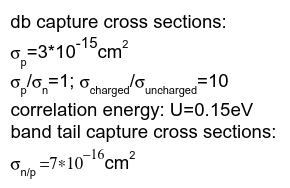

Sample name: IP/PostLaser
Sample thickness: 0.014cm
Dopant type: n-type
Sample doping: 2.384042e+15cm-3
A total of 15 points will be analysed from the experimental lifetime curve.
The RMSE is 1.6640887437704257
The RMSE is 1.6655422965422726
The RMSE is 1.6361893569352017
The RMSE is 1.6640887437704257
The RMSE is 1.643314580676395
The RMSE is 1.631913893881692
The RMSE is 1.6162655777276118
The RMSE is 1.6009257247487012
The RMSE is 1.5717638083439305
The RMSE is 1.573651576646161
The RMSE is 1.5413471812263695
The RMSE is 1.4996636603935756
The RMSE is 1.4855887758584956
The RMSE is 1.430065578765597
The RMSE is 1.430919163220775
The RMSE is 1.355008370946555
The RMSE is 1.2755657313764681
The RMSE is 1.273240386580002
The RMSE is 1.1947528794937516
The RMSE is 1.183888642052557
The RMSE is 1.1074223908341512
The RMSE is 1.0455334487550854
The RMSE is 0.9448689093343716
The RMSE is 0.9418746491762818
The RMSE is 0.854310371975853
The RMSE is 0.8179910077316673
The RMSE is 0.723469018

KeyboardInterrupt: 

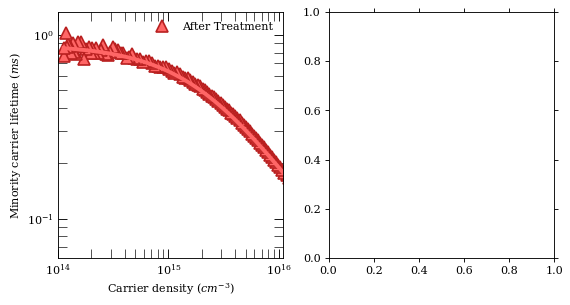

In [7]:
fig1, ax = plt.subplots(1, 2, figsize=(8,4))

for currentSample, filename in enumerate(filenameArray):
    wb = openpyxl.load_workbook(filename+'.xlsm', data_only=True)
    ws_calc = wb['Calc']
    dn_exp_full = []
    tau_exp_full = []
    for iteration in np.linspace(13,131,119):
        dn_exp_full.append(ws_calc['O{}'.format(int(iteration))].value)
        tau_exp_full.append(ws_calc['P{}'.format(int(iteration))].value)
    dn_exp_full = np.array(dn_exp_full)
    tau_exp_full = np.array(tau_exp_full)
    tau_exp_full=tau_exp_full[dn_exp_full>1e14]
    dn_exp_full=dn_exp_full[dn_exp_full>1e14]
    dn_exp = dn_exp_full[5::pointToSkip]
    tau_exp = tau_exp_full[5::pointToSkip]
    ws_user = wb['User']
    W = ws_user['B{}'.format(6)].value
    dopanttype = ws_user['D{}'.format(6)].value
    Ndop_bulk = ws_user['J{}'.format(9)].value
    print('Sample name: '+filename)
    print('Sample thickness: '+str(W)+'cm')
    print('Dopant type: '+dopanttype)
    print('Sample doping: '+"{:e}".format(Ndop_bulk)+'cm-3')
    print('A total of '+str(len(dn_exp))+' points will be analysed from the experimental lifetime curve.')
    
   
   
    initial_guess = [1E10, 1E10, 0]
    try:
        result = optimize.minimize(calculate_mean_square_error, initial_guess, method='Nelder-Mead',options={'maxiter': maxiterations})
    except RuntimeError:
        print("Max number of iterations reached")
    
    Ditoptimum = result.x[1]
    Qoptimumi = -result.x[0]
    Ditbandedgeoptimum = 0
    RMSE = calculate_mean_square_error((Qoptimumi, Ditoptimum, Ditbandedgeoptimum))
    MAE = calculate_mean_absolute_error((Qoptimumi, Ditoptimum, Ditbandedgeoptimum))
    MBE = calculate_mean_bias_error((Qoptimumi, Ditoptimum, Ditbandedgeoptimum))
    
    print('Optimum Dit = '+"{:e}".format(Ditoptimum)+'cm-2')
    print('Optimum Q = '+"{:e}".format(Qoptimumi)+'cm-2')
    
    #iVoc_exp = 0.02569*np.ln(((Ndop_bulk+dn_exp)*(dn_exp)/7.4E+019))
    Qoptimum = Qoptimumi * constants.e
    taueff(dn_exp_full,tau_exp_full,Ditoptimum,Ditbandedgeoptimum,Qoptimum,export=True)
    
    qsamples[currentSample]=Qoptimumi
    ditsamples[currentSample]=Ditoptimum
    tausamples[currentSample]=find_lifetime(dn_exp_full,tau_exp_full,1E15)
    
    df1 = pd.DataFrame([[s0n,s0p,splusn,sminusp,U,tau_SRH,'',Qoptimumi,Ditoptimum,RMSE,MAE,MBE]],
                   index=['Parameters'],
                   columns=['s0n','s0p','splusn','sminusp','U','tau_SRH','','Q','Dit','RMSE','MAE','MBE'])
    df1.to_excel(filename+'.xlsx')

ax[0].set_ylim([0.1,12])
ax[1].set_yscale('log')
ax[1].set_xlabel('Time (weeks)')
ax[1].set_ylabel('-Q  $(cm^{-2})')

'''
for (x_val, q_val, color) in zip(np.arange(len(filenameArray)), np.abs(qsamples), colors_marker[:7]):
    print(x_val, q_val, color)
    ax[1].plot(
        [x_val],
        [q_val],
        marker=symbols[x_val],
        markersize=10,
        linestyle='none',
        markerfacecolor=colors_line[x_val],
        markeredgecolor=colors_marker[x_val],
        label=f'Sample {1}',
    )
'''

for (x_val, q_val, color) in zip(np.arange(len(filenameArray)), np.abs(ditsamples), colors_marker[:7]):
    print(x_val, q_val, color)
    ax[1].plot(
        [x_val],
        [q_val],
        marker=symbols[x_val],
        markersize=10,
        linestyle='none',
        markerfacecolor=colors_line[x_val],
        markeredgecolor=colors_marker[x_val],
        label=f'Sample {1}',
    )

ax[1].tick_params(axis='both', which='major', direction='in', length=8)
ax[1].set_xlabel('Time (weeks)')
def lookup(Y, yval, X):
    Y = np.array(Y)
    index = np.argmin(abs(Y-yval))
    if len(X) == 0:  # Check if X is empty
        return index
    else:
        return X[index]
ax[1].set_ylabel('Dit  $(cm^{-2})$')
ax[1].set_yscale('log')
plt.tight_layout()

fig1.savefig(filename+'_lifetime{}.png'.format(datetime.datetime.now().strftime('%y%m%d-%H%M%S')))

fig3, axs = plt.subplots(3, sharex=True, sharey=False, gridspec_kw={'hspace': 0})
fig3.set_size_inches(12, 12)
axs[0].scatter(filenameArray,tausamples)
axs[0].set_ylim([1E-6,0.01])
axs[0].tick_params(axis='both', which='major', direction='in', length=8)
axs[0].set_ylabel('Lifetime  $(\mu s)$')
axs[1].scatter(filenameArray,ditsamples)
axs[1].set_ylim([np.min(ditsamples)/1.2,np.max(ditsamples)*1.2])
axs[1].tick_params(axis='both', which='major', direction='in', length=8)
axs[1].set_ylabel('Dit  $(cm^{-2})$')
axs[1].set_yscale('log')
axs[2].scatter(filenameArray,qsamples)
axs[2].tick_params(axis='both', which='major', direction='in', length=8)
#axs[2].set_ylim([np.min(-qsamples)/3,np.max(-qsamples)*3])
axs[2].set_ylabel('-Q  $(cm^{-2})$')
axs[2].set_yscale('log')
plt.xlabel('Sample name')

# Hide x labels and tick labels for all but bottom plot.
for ax in axs:
    ax.label_outer()

fig3.savefig('Summary.png')

0 7536226146.846851 #B92020
1 15276895006.081024 #B96D20
2 21425247121.10489 #B9B920
3 25731058793.392998 #20B920
4 24585570355.13293 #20B9B9
5 25624769773.317738 #2020B9
6 27458795608.224525 #6D20B9


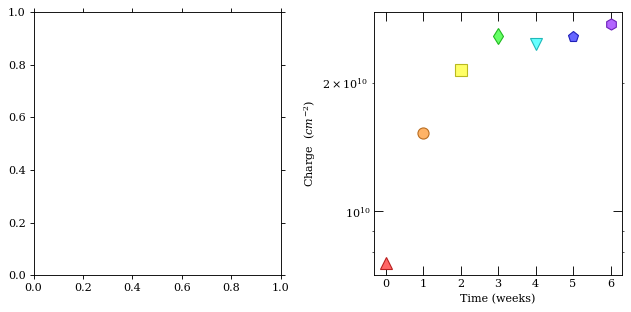

In [10]:
fig, ax = plt.subplots(1, 2, figsize=(8,4))

ax[1].set_yscale('log')
ax[1].set_xlabel('Time (weeks)')
ax[1].set_ylabel('-Q  $(cm^{-2})')

for (x_val, q_val, color) in zip(np.arange(len(filenameArray)), np.abs(ditsamples), colors_marker[:7]):
    print(x_val, q_val, color)
    ax[1].plot(
        [x_val],
        [q_val],
        marker=symbols[x_val],
        markersize=10,
        linestyle='none',
        markerfacecolor=colors_line[x_val],
        markeredgecolor=colors_marker[x_val],
        label=f'Sample {1}',
    )

ax[1].tick_params(axis='both', which='major', direction='in', length=8)
ax[1].set_xlabel('Time (weeks)')
ax[1].set_ylabel('Charge  $(cm^{-2})$')
ax[1].set_yscale('log')
plt.tight_layout()

# Figure 1

In [ ]:
E = np.linspace(Ev, Ec, 100000) 
dn_array = np.logspace(14, 17)
Qtotarray = np.logspace(6, 13, 2)
s0n = 1E-17
s0p = 1E-17
splusn = 1E-16
sminusp = 1E-16

colors = pl.cm.hsv(np.linspace(0,1,12))

fig, ax = plt.subplots(1, 2, figsize=(8,4))

for i,Qtot in enumerate(np.logspace(10,11.5,10)):
    U = 0.15 
    Ditmax = 1E10
    gaussianWidth = 0.18
    Ditposition = 0.56
    Qtot = -Qtot * constants.e
    params_g = (Ditposition,Ditmax,gaussianWidth)
    Dit_g = Dig_func(E, *params_g)
    tau_surface_array = []
    for count, dn in enumerate(dn_array):
        Delta_n = dn
        Ndop = Ndop_bulk
        dop_type = dop_type_bulk
        n0 = Ndop*(1-dop_type) + ni_b**2/Ndop*dop_type
        p0 = Ndop*dop_type + ni_b**2/Ndop*(1 - dop_type)
        n = Delta_n + n0
        p = Delta_n + p0
        tau_surface = surfaceLifetime(n0,p0,n,p,Delta_n,Qtot, T, Ndop_emitter, Ndop_bulk, dop_type_emitter, dop_type_bulk, dn,Dit_g)
        tau_surface_array.append(tau_surface*1E3)
    ax[0].loglog(dn_array,tau_surface_array,color=colors[i],linewidth=2)
arrow = patches.FancyArrowPatch(
    (1E15, 1.5), (1E15, 100), arrowstyle='->', mutation_scale=15, color='black')
ax[0].text(-0.1, 1.05, '(a)', transform=ax[0].transAxes, fontsize=12, va='bottom', ha='left')
ax[0].add_patch(arrow)
ax[0].text(1.5e15, 100, 'Higher charge', fontsize=10, color='black')

for i,Ditmax in enumerate(np.logspace(10,12,10)):
    U = 0.15 
    gaussianWidth = 0.18
    Ditposition = 0.56
    Qtot = -1e10 * constants.e
    params_g = (Ditposition,Ditmax,gaussianWidth)
    Dit_g = Dig_func(E, *params_g)
    tau_surface_array = []
    for count, dn in enumerate(dn_array):
        Delta_n = dn
        Ndop = Ndop_bulk
        dop_type = dop_type_bulk
        n0 = Ndop*(1-dop_type) + ni_b**2/Ndop*dop_type
        p0 = Ndop*dop_type + ni_b**2/Ndop*(1 - dop_type)
        n = Delta_n + n0
        p = Delta_n + p0
        tau_surface = surfaceLifetime(n0,p0,n,p,Delta_n,Qtot, T, Ndop_emitter, Ndop_bulk, dop_type_emitter, dop_type_bulk, dn,Dit_g)
        tau_surface_array.append(tau_surface*1E3)
    ax[1].loglog(dn_array,tau_surface_array,color=colors[i],linewidth=2)
arrow = patches.FancyArrowPatch(
    (1E15, 0.01), (1E15, 10), arrowstyle='<-', mutation_scale=15, color='black')
ax[1].text(-0.1, 1.05, '(b)', transform=ax[1].transAxes, fontsize=12, va='bottom', ha='left')
ax[1].add_patch(arrow)
ax[1].text(1.4e15, 0.02, 'Higher Dit', fontsize=10, color='black')

for axis in ax:
    axis.yaxis.set_major_formatter(ScalarFormatter(useMathText=False))
    axis.set_xlim([1e14, 1.1e16])
    axis.set_xlabel('Carrier density $(cm^{-3})$')
    axis.set_ylabel('Minority carrier lifetime $(ms)$')
    axis.tick_params(axis='both', which='major', direction='in', length=8)
    axis.tick_params(axis='both', which='minor', direction='in', length=8)

plt.tight_layout()
plt.show()
fig.savefig('figure 1.png')

# Figure 2

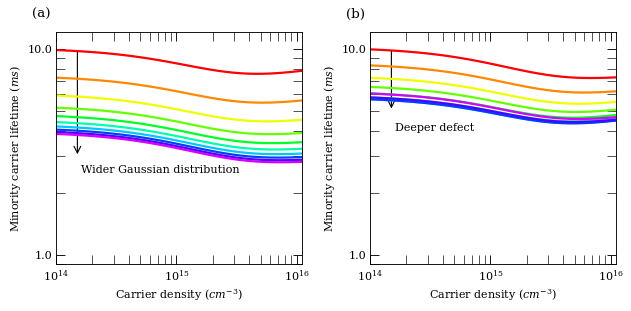

In [18]:
E = np.linspace(Ev, Ec, 100000) 
dn_array = np.logspace(14, 17)
Qtotarray = np.logspace(6, 13, 2)
s0n = 1E-17
s0p = 1E-17
splusn = 1E-16
sminusp = 1E-16

colors = pl.cm.hsv(np.linspace(0,1,12))

fig, ax = plt.subplots(1, 2, figsize=(8,4))

for i,gaussianWidth in enumerate(np.linspace(0.1,0.5,10)):
    U = 0.15 
    Ditmax = 1E10
    Ditposition = 0.56
    Qtot = -5e10 * constants.e
    params_g = (Ditposition,Ditmax,gaussianWidth)
    Dit_g = Dig_func(E, *params_g)
    tau_surface_array = []
    for count, dn in enumerate(dn_array):
        Delta_n = dn
        Ndop = Ndop_bulk
        dop_type = dop_type_bulk
        n0 = Ndop*(1-dop_type) + ni_b**2/Ndop*dop_type
        p0 = Ndop*dop_type + ni_b**2/Ndop*(1 - dop_type)
        n = Delta_n + n0
        p = Delta_n + p0
        tau_surface = surfaceLifetime(n0,p0,n,p,Delta_n,Qtot, T, Ndop_emitter, Ndop_bulk, dop_type_emitter, dop_type_bulk, dn,Dit_g)
        tau_surface_array.append(tau_surface*1E3)
    ax[0].loglog(dn_array,tau_surface_array,color=colors[i],linewidth=2)
arrow = patches.FancyArrowPatch(
    (1.5E14, 3), (1.5E14, 10), arrowstyle='<-', mutation_scale=15, color='black')
ax[0].text(-0.1, 1.05, '(a)', transform=ax[0].transAxes, fontsize=12, va='bottom', ha='left')
ax[0].add_patch(arrow)
ax[0].text(1.6e14, 2.5, 'Wider Gaussian distribution', fontsize=10, color='black')

for i,Ditposition in enumerate(np.linspace(0.1,0.55,10)):
    U = 0.15 
    gaussianWidth = 0.18
    Ditmax = 1E10
    Qtot = -5e10 * constants.e
    params_g = (Ditposition,Ditmax,gaussianWidth)
    Dit_g = Dig_func(E, *params_g)
    tau_surface_array = []
    for count, dn in enumerate(dn_array):
        Delta_n = dn
        Ndop = Ndop_bulk
        dop_type = dop_type_bulk
        n0 = Ndop*(1-dop_type) + ni_b**2/Ndop*dop_type
        p0 = Ndop*dop_type + ni_b**2/Ndop*(1 - dop_type)
        n = Delta_n + n0
        p = Delta_n + p0
        tau_surface = surfaceLifetime(n0,p0,n,p,Delta_n,Qtot, T, Ndop_emitter, Ndop_bulk, dop_type_emitter, dop_type_bulk, dn,Dit_g)
        tau_surface_array.append(tau_surface*1E3)
    ax[1].loglog(dn_array,tau_surface_array,color=colors[i],linewidth=2)
arrow = patches.FancyArrowPatch(
    (1.5E14, 5), (1.5E14, 10), arrowstyle='<-', mutation_scale=15, color='black')
ax[1].text(-0.1, 1.05, '(b)', transform=ax[1].transAxes, fontsize=12, va='bottom', ha='left')
ax[1].add_patch(arrow)
ax[1].text(1.6e14, 4, 'Deeper defect', fontsize=10, color='black')

for axis in ax:
    axis.yaxis.set_major_formatter(ScalarFormatter(useMathText=False))
    axis.set_xlim([1e14, 1.1e16])
    axis.set_ylim([0.9,12])
    axis.set_xlabel('Carrier density $(cm^{-3})$')
    axis.set_ylabel('Minority carrier lifetime $(ms)$')
    axis.tick_params(axis='both', which='major', direction='in', length=8)
    axis.tick_params(axis='both', which='minor', direction='in', length=8)

plt.tight_layout()
plt.show()
fig.savefig('figure 2.png')

# Figure 3

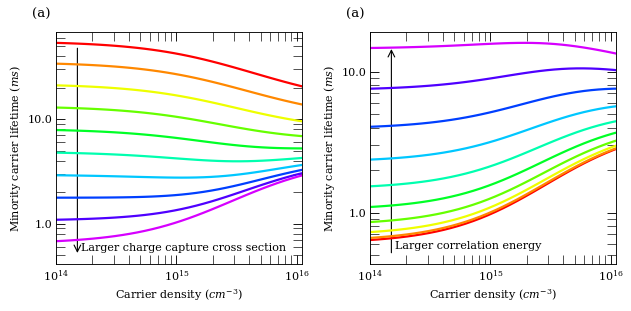

In [19]:
E = np.linspace(Ev, Ec, 100000) 
dn_array = np.logspace(14, 17)
Qtotarray = np.logspace(6, 13, 2)
s0n = 1E-17
s0p = 1E-17
splusn = 1E-16
sminusp = 1E-16

colors = pl.cm.hsv(np.linspace(0,1,12))

fig, ax = plt.subplots(1, 2, figsize=(8,4))

for i,scharged in enumerate(np.logspace(-17,-15,10)):
    splusn = scharged
    sminusp = scharged
    U = 0.15 
    Ditmax = 1E10
    gaussianWidth = 0.18
    Ditposition = 0.56
    Qtot = -5e10 * constants.e
    params_g = (Ditposition,Ditmax,gaussianWidth)
    Dit_g = Dig_func(E, *params_g)
    tau_surface_array = []
    for count, dn in enumerate(dn_array):
        Delta_n = dn
        Ndop = Ndop_bulk
        dop_type = dop_type_bulk
        n0 = Ndop*(1-dop_type) + ni_b**2/Ndop*dop_type
        p0 = Ndop*dop_type + ni_b**2/Ndop*(1 - dop_type)
        n = Delta_n + n0
        p = Delta_n + p0
        tau_surface = surfaceLifetime(n0,p0,n,p,Delta_n,Qtot, T, Ndop_emitter, Ndop_bulk, dop_type_emitter, dop_type_bulk, dn,Dit_g)
        tau_surface_array.append(tau_surface*1E3)
    ax[0].loglog(dn_array,tau_surface_array,color=colors[i],linewidth=2)
arrow = patches.FancyArrowPatch(
    (1.5E14, 0.5), (1.5E14, 50), arrowstyle='<-', mutation_scale=15, color='black')
ax[0].text(-0.1, 1.05, '(a)', transform=ax[0].transAxes, fontsize=12, va='bottom', ha='left')
ax[0].add_patch(arrow)
ax[0].text(1.6e14, 0.55, 'Larger charge capture cross section', fontsize=10, color='black')
ax[0].set_xlim([1e14, 1.1e16])
ax[0].set_xlabel('Carrier density $(cm^{-3})$')
ax[0].set_ylabel('Minority carrier lifetime $(ms)$')
ax[0].tick_params(axis='both', which='major', direction='in', length=8)
ax[0].tick_params(axis='both', which='minor', direction='in', length=8)

for i,U in enumerate(np.linspace(0.05,0.7,10)):
    Ditmax = 1E10
    gaussianWidth = 0.18
    Ditposition = 0.56
    Qtot = -5e10 * constants.e
    params_g = (Ditposition,Ditmax,gaussianWidth)
    Dit_g = Dig_func(E, *params_g)
    tau_surface_array = []
    for count, dn in enumerate(dn_array):
        Delta_n = dn
        Ndop = Ndop_bulk
        dop_type = dop_type_bulk
        n0 = Ndop*(1-dop_type) + ni_b**2/Ndop*dop_type
        p0 = Ndop*dop_type + ni_b**2/Ndop*(1 - dop_type)
        n = Delta_n + n0
        p = Delta_n + p0
        tau_surface = surfaceLifetime(n0,p0,n,p,Delta_n,Qtot, T, Ndop_emitter, Ndop_bulk, dop_type_emitter, dop_type_bulk, dn,Dit_g)
        tau_surface_array.append(tau_surface*1E3)
    ax[1].loglog(dn_array,tau_surface_array,color=colors[i],linewidth=2)
arrow = patches.FancyArrowPatch(
    (1.5E14, 0.5), (1.5E14,15), arrowstyle='->', mutation_scale=15, color='black')
ax[1].text(-0.1, 1.05, '(a)', transform=ax[1].transAxes, fontsize=12, va='bottom', ha='left')
ax[1].add_patch(arrow)
ax[1].text(1.6e14, 0.55, 'Larger correlation energy', fontsize=10, color='black')

for axis in ax:
    axis.yaxis.set_major_formatter(ScalarFormatter(useMathText=False))
    axis.set_xlim([1e14, 1.1e16])
    axis.set_xlabel('Carrier density $(cm^{-3})$')
    axis.set_ylabel('Minority carrier lifetime $(ms)$')
    axis.tick_params(axis='both', which='major', direction='in', length=8)
    axis.tick_params(axis='both', which='minor', direction='in', length=8)

plt.tight_layout()
plt.show()
fig.savefig('figure 3.png')

In [40]:
dn_exp

array([6.23131280e+15, 4.63654138e+15, 3.65245348e+15, 2.97478188e+15,
       2.47530504e+15, 2.09534297e+15, 1.79106916e+15, 1.54448672e+15,
       1.33954222e+15, 1.16628881e+15, 1.02089302e+15, 8.97589548e+14,
       7.91489272e+14, 7.00538955e+14, 6.17353466e+14, 5.46868821e+14,
       4.83397007e+14, 4.28200947e+14, 3.82770205e+14, 3.37691944e+14,
       3.01295484e+14, 2.68303291e+14, 2.38839016e+14, 2.09148140e+14,
       1.89009211e+14, 1.67106613e+14, 1.46542329e+14, 1.32839390e+14,
       1.17516303e+14])